# EDA по данным LMS Цифриум

Цель этого ноутбука — подготовить понятный и воспроизводимый аналитический слой для дальнейшего выбора целевого признака и обучения модели.

В этом ноутбуке мы **не пытаемся сразу построить финальный датасет любой ценой**. Вместо этого двигаемся поэтапно:

1. загружаем и выравниваем таблицы;
2. проверяем качество данных и ищем очевидные проблемы;
3. проводим черновую предобработку по каждой таблице отдельно;
4. строим только самые безопасные агрегаты и merge;
5. подготавливаем основу для проверки гипотез о более сложных связях между таблицами.

Базовая логика анализа:
- сначала техническая чистота данных;
- затем проверка корректности ключей и связей;
- только после этого — нетривиальные merge и построение сложных признаков.


Этот ноутбук задаёт видимый сквозной EDA- и feature-engineering пайплайн для кейса по аналитике LMS.

Проекту нужен один прозрачный аналитический артефакт, который начинается с сырых таблиц, проверяет логику сущностей, строит интерпретируемые блоки признаков и заканчивается master-таблицей, готовой для обучения.

Входные данные:
Сырые таблицы LMS из `data/raw`.

Ожидаемый результат:
Одна master-таблица признаков, где строго одна строка соответствует одному `users_course_id`, а также экспортированные промежуточные блоки, саммари и графики в `data/AGENT`.

# Инициализация путей и импортов

In [12]:
import gc
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from IPython.display import display, Markdown

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

print(PROJECT_ROOT)

os.environ['PYTHONIOENCODING'] = 'utf-8'
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts import (
    BLOCK_EXPORT_NAMES,
    CORE_ENTITY_KEY,
    FIGURES_DIR,
    TABLES_DIR,
    build_access_history_features,
    build_course_action_features,
    build_course_structure_features,
    build_key_diagnostics,
    build_media_features,
    build_missingness_summary,
    build_time_window_features,
    build_user_answer_features,
    build_user_lesson_features,
    build_user_training_features,
    build_users_base_features,
    build_users_courses_base,
    drop_service_columns,
    ensure_output_directories,
    load_all_tables,
    describe_loaded_table,
    normalize_id_columns,
    save_dataframe,
    save_summary,
    assemble_master_user_course_table,
    build_direct_link_diagnostics,
    build_route_coverage,
)

plt.style.use('ggplot')
pd.set_option('display.max_rows', None)      # все строки
pd.set_option('display.max_columns', None)   # все столбцы
pd.set_option('display.width', None)         # не разрывать строки по ширине консоли
pd.set_option('display.max_colwidth', None)  # не обрезать текст внутри ячеек
pd.set_option('display.expand_frame_repr', False) # не переносить широкие таблицы на новые строки


def savefig(file_name: str) -> None:
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / file_name, dpi=160, bbox_inches='tight')


def summary_frame(summary: dict) -> pd.DataFrame:
    return pd.DataFrame([summary])


ensure_output_directories()

C:\Repos\Xakaton


ImportError: cannot import name 'build_route_coverage' from 'scripts' (C:\Repos\Xakaton\scripts\__init__.py)

# 1. Черновая предобработка

- выполняется первичный аудит сырого датасета и текущей логики загрузки таблиц;
- проверяется полнота подключённых источников и выявляются пропущенные, но содержательно важные таблицы;
- фиксируются базовые характеристики таблиц: размерности, ключевые идентификаторы, временные поля, предполагаемый grain;
- проводится черновая проверка структуры данных, типов столбцов и общего профиля пропусков;
- формируется надёжная основа для следующего этапа: содержательной предобработки, очистки и проверки связей между таблицами.

## 1.1 Загрузка таблиц

In [2]:
table_names = [
    'users_courses',
    'users',
    'lessons',
    'lesson_tasks',
    'trainings',
    'user_lessons',
    'user_trainings',
    'user_answers',
    'wk_users_courses_actions',
    'wk_media_view_sessions',
    'user_access_histories',
    'user_award_badges',
    'award_badges',
    'groups',
    'homeworks',
    'homework_items',
    'stats__module_1',
    'stats__module_2',
    'stats__module_3',
    'stats__module_4',
]

dfs, tables_overview = load_all_tables(table_names)
tables_overview

,table_name,role,grain_guess,rows,cols,memory_mb,duplicate_full_rows,all_null_columns,mean_missing_share,max_missing_share,date_columns,key_like_columns,all_columns
0,user_answers,answer event log,user_id-level or user-event-level,15176182,12,3376.69,4950084,0,0.1141,0.6759,submitted_at,"user_id, task_id, resource_id","user_id, task_id, attempts, solved, points, max_attempts, skipped, resource_type, resource_id, submitted_at, wk_partial_answer, async_check_status"
1,wk_users_courses_actions,course activity event log,users_course_id-level / user-course,12909207,7,2278.05,5490050,0,0.2854,0.9988,"created_at, updated_at","user_id, users_course_id, sourceable_id, lesson_id","user_id, users_course_id, sourceable_id, action, created_at, updated_at, lesson_id"
2,user_lessons,user progress by lesson,users_course_id-level / user-course,3070664,10,653.78,0,0,0.0121,0.0603,,"user_id, lesson_id, users_course_id","user_id, lesson_id, video_visited, translation_visited, users_course_id, solved, solved_tasks_count, wk_points, video_viewed, wk_solved_task_count"
3,wk_media_view_sessions,media consumption event log,grain not inferred,852358,7,123.79,3558,0,0.0000,0.0000,started_at,"resource_id, viewer_id","resource_type, resource_id, viewer_id, segments_total, viewed_segments_count, started_at, kind"
4,user_access_histories,access history / administrative timeline,users_course_id-level / user-course,667124,4,15.91,355372,0,0.0000,0.0000,"access_started_at, access_expired_at",users_course_id,"users_course_id, access_started_at, access_expired_at, activator_class"
5,user_trainings,user progress by training,user_id-level or user-event-level,427628,12,78.73,0,0,0.0026,0.0078,"started_at, finished_at, mark_saved_at","user_id, training_id","user_id, training_id, solved_tasks_count, earned_points, type, state, submitted_answers_count, started_at, finished_at, attempts, mark, mark_saved_at"
6,users_courses,base enrollment / user-course registry,user_id + course_id-level,290835,13,58.15,0,0,0.1507,0.9988,"created_at, updated_at, access_finished_at, wk_officially_started_at, wk_course_completed_at","id, user_id, course_id","id, user_id, course_id, state, created_at, updated_at, access_finished_at, wk_points, wk_max_points, wk_max_viewable_lessons, wk_max_task_count, wk_officially_started_at, wk_course_completed_at"
7,user_award_badges,user achievements,user_id-level or user-event-level,252843,3,19.29,0,0,0.0000,0.0000,created_at,"award_badge_id, user_id","award_badge_id, user_id, created_at"
8,users,user profile / demographics,entity table with primary id,95395,13,29.01,0,0,0.2154,0.9811,"created_at, updated_at, grade_changed_at","id, grade_id, d_wk_school_id, d_wk_municipal_id, d_wk_region_id","id, created_at, updated_at, type, sign_in_count, grade_id, subscribed, timezone, grade_changed_at, d_wk_school_id, d_wk_municipal_id, d_wk_region_id, wk_gender"
9,lesson_tasks,lesson-task linkage,lesson_id-level,29544,5,4.12,0,0,0.0000,0.0000,,"id, lesson_id, task_id","id, lesson_id, task_id, position, task_required"


In [3]:
for table_name in table_names:
    display(Markdown(f"### Таблица: `{table_name}`"))
    display(describe_loaded_table(table_name, dfs[table_name]))


### Таблица: `users_courses`

,column_name,dtype,missing_count,missing_share,nunique,is_key_like,is_datetime_expected
0,course_id,object,0,0.0000,99,True,False
1,id,int64,0,0.0000,290835,True,False
2,user_id,object,0,0.0000,88319,True,False
3,wk_course_completed_at,datetime64[ns],290481,0.9988,353,False,True
4,wk_officially_started_at,datetime64[ns],193970,0.6669,136,False,True
5,wk_points,Float64,84910,0.2920,12800,False,False
6,wk_max_points,Float64,125,0.0004,77,False,False
7,wk_max_task_count,Float64,125,0.0004,81,False,False
8,wk_max_viewable_lessons,Float64,125,0.0004,25,False,False
9,access_finished_at,datetime64[ns],94,0.0003,460,False,True


### Таблица: `users`

,column_name,dtype,missing_count,missing_share,nunique,is_key_like,is_datetime_expected
0,d_wk_municipal_id,object,31302,0.3281,1152,True,False
1,d_wk_region_id,object,31302,0.3281,202,True,False
2,d_wk_school_id,object,31302,0.3281,3219,True,False
3,grade_id,object,0,0.0000,13,True,False
4,id,int64,0,0.0000,95395,True,False
5,grade_changed_at,datetime64[ns],93591,0.9811,1646,False,True
6,wk_gender,category,79449,0.8328,2,False,False
7,timezone,category,178,0.0019,141,False,False
8,created_at,datetime64[ns],0,0.0000,65681,False,True
9,sign_in_count,object,0,0.0000,487,False,False


### Таблица: `lessons`

...

,column_name,dtype,missing_count,missing_share,nunique,is_key_like,is_datetime_expected
0,course_id,int64,0,0.000,2,True,False
1,teacher_id,int64,0,0.000,36,True,False
2,user_id,int64,0,0.000,1955,True,False
3,Балл ПА,Float64,170,0.087,51,False,False
4,Дата сдачи ПА (МСК),datetime64[ns],170,0.087,25,False,True
5,id параллели,int64,0,0.000,71,False,False
6,Кружок,category,0,0.000,71,False,False
7,Посетил урок в онлайне,category,0,0.000,2,False,False
8,Посмотрел уроков на 80%,Float64,0,0.000,21,False,False
9,Пройден тек.контроль,category,0,0.000,2,False,False


### Таблица: `stats__module_3`

,column_name,dtype,missing_count,missing_share,nunique,is_key_like,is_datetime_expected
0,course_id,int64,0,0.0000,2,True,False
1,teacher_id,int64,0,0.0000,36,True,False
2,user_id,int64,0,0.0000,1785,True,False
3,Балл ПА,Float64,78,0.0437,62,False,False
4,Дата сдачи ПА (МСК),datetime64[ns],78,0.0437,18,False,True
5,id параллели,int64,0,0.0000,66,False,False
6,Кружок,category,0,0.0000,66,False,False
7,Посетил урок в онлайне,category,0,0.0000,2,False,False
8,Посмотрел уроков на 80%,Float64,0,0.0000,19,False,False
9,Пройден тек.контроль,category,0,0.0000,2,False,False


### Таблица: `stats__module_4`

,column_name,dtype,missing_count,missing_share,nunique,is_key_like,is_datetime_expected
0,course_id,float64,18,0.0105,2,True,False
1,teacher_id,float64,18,0.0105,33,True,False
2,user_id,int64,0,0.0000,1707,True,False
3,id параллели,float64,18,0.0105,63,False,False
4,Кружок,category,18,0.0105,2,False,False
5,Посетил урок в онлайне,category,0,0.0000,2,False,False
6,Посмотрел уроков на 80%,Float64,0,0.0000,9,False,False
7,Пройден тек.контроль,category,0,0.0000,1,False,False
8,Пройдена рефлексия,category,0,0.0000,1,False,False
9,Просмотрено 720ед видеоконт и 80% ур,category,0,0.0000,1,False,False


## 1.2 Аудит сырых данных и общий обзор

Аудит сырых данных показывает масштаб таблиц до применения любой логики объединения или агрегации.

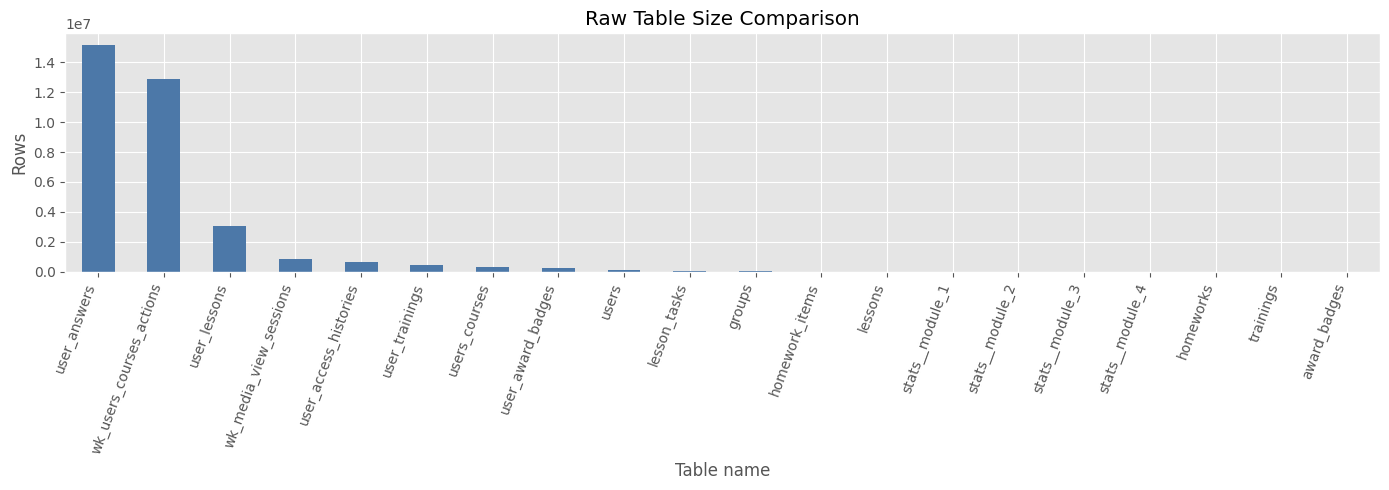

,table_name,role,grain_guess,rows,cols,memory_mb,duplicate_full_rows,all_null_columns,mean_missing_share,max_missing_share,date_columns,key_like_columns,all_columns
0,user_answers,answer event log,user_id-level or user-event-level,15176182,12,3376.69,4950084,0,0.1141,0.6759,submitted_at,"user_id, task_id, resource_id","user_id, task_id, attempts, solved, points, max_attempts, skipped, resource_type, resource_id, submitted_at, wk_partial_answer, async_check_status"
1,wk_users_courses_actions,course activity event log,users_course_id-level / user-course,12909207,7,2278.05,5490050,0,0.2854,0.9988,"created_at, updated_at","user_id, users_course_id, sourceable_id, lesson_id","user_id, users_course_id, sourceable_id, action, created_at, updated_at, lesson_id"
2,user_lessons,user progress by lesson,users_course_id-level / user-course,3070664,10,653.78,0,0,0.0121,0.0603,,"user_id, lesson_id, users_course_id","user_id, lesson_id, video_visited, translation_visited, users_course_id, solved, solved_tasks_count, wk_points, video_viewed, wk_solved_task_count"
3,wk_media_view_sessions,media consumption event log,grain not inferred,852358,7,123.79,3558,0,0.0000,0.0000,started_at,"resource_id, viewer_id","resource_type, resource_id, viewer_id, segments_total, viewed_segments_count, started_at, kind"
4,user_access_histories,access history / administrative timeline,users_course_id-level / user-course,667124,4,15.91,355372,0,0.0000,0.0000,"access_started_at, access_expired_at",users_course_id,"users_course_id, access_started_at, access_expired_at, activator_class"
5,user_trainings,user progress by training,user_id-level or user-event-level,427628,12,78.73,0,0,0.0026,0.0078,"started_at, finished_at, mark_saved_at","user_id, training_id","user_id, training_id, solved_tasks_count, earned_points, type, state, submitted_answers_count, started_at, finished_at, attempts, mark, mark_saved_at"
6,users_courses,base enrollment / user-course registry,user_id + course_id-level,290835,13,58.15,0,0,0.1507,0.9988,"created_at, updated_at, access_finished_at, wk_officially_started_at, wk_course_completed_at","id, user_id, course_id","id, user_id, course_id, state, created_at, updated_at, access_finished_at, wk_points, wk_max_points, wk_max_viewable_lessons, wk_max_task_count, wk_officially_started_at, wk_course_completed_at"
7,user_award_badges,user achievements,user_id-level or user-event-level,252843,3,19.29,0,0,0.0000,0.0000,created_at,"award_badge_id, user_id","award_badge_id, user_id, created_at"
8,users,user profile / demographics,entity table with primary id,95395,13,29.01,0,0,0.2154,0.9811,"created_at, updated_at, grade_changed_at","id, grade_id, d_wk_school_id, d_wk_municipal_id, d_wk_region_id","id, created_at, updated_at, type, sign_in_count, grade_id, subscribed, timezone, grade_changed_at, d_wk_school_id, d_wk_municipal_id, d_wk_region_id, wk_gender"
9,lesson_tasks,lesson-task linkage,lesson_id-level,29544,5,4.12,0,0,0.0000,0.0000,,"id, lesson_id, task_id","id, lesson_id, task_id, position, task_required"


In [4]:
raw_audit = tables_overview.sort_values('rows', ascending=False).reset_index(drop=True)
ax = raw_audit.plot.bar(x='table_name', y='rows', figsize=(14, 5), legend=False, color='#4C78A8')
ax.set_title('Raw Table Size Comparison')
ax.set_xlabel('Table name')
ax.set_ylabel('Rows')
plt.xticks(rotation=70, ha='right')
savefig('raw_table_size_comparison_AGENT.png')
plt.show()

raw_audit

По результатам первичного аудита видно, что датасет включает таблицы существенно разного масштаба. Наибольший объём имеют событийные логи пользовательской активности, тогда как справочные и структурные таблицы заметно компактнее. Это подтверждает, что дальнейший EDA должен различать таблицы по их роли: одни описывают поток действий пользователей, другие — структуру курсов и агрегированные статусы прогресса. На текущем этапе мы получаем только общий обзор масштаба данных; для полноценного аудита далее требуется отдельно проверить ключи, пропуски, типы полей и согласованность grain между таблицами.

## 1.3 Проверка центральной сущности и прямых связей

На этом шаге мы определяем, какая сущность будет базовой для дальнейшего анализа и построения итоговой мастер-таблицы.  
Поскольку задача связана с прогнозированием поведения студента внутри конкретного курса, в качестве естественного уровня наблюдения рассматривается связка «пользователь–курс», представленная в таблице `users_courses`.

В рамках проверки решаются две подзадачи:
- оценивается, насколько устойчивы кандидатные ключи таблицы `users_courses`, прежде всего `id` и пара `(user_id, course_id)`;
- отдельно анализируются таблицы, которые уже содержат `users_course_id` напрямую и, следовательно, потенциально могут агрегироваться к целевому grain без сложного восстановления маршрутов связи.

Этот шаг необходим для того, чтобы до начала merge:
- зафиксировать корректный уровень агрегации;
- избежать размножения строк из-за неуникальных ключей;
- отделить таблицы с прямой привязкой к сущности `user-course` от таблиц, для которых связь ещё нужно восстанавливать через промежуточные объекты.

In [7]:
entity_key_diagnostics = build_key_diagnostics(
    dfs["users_courses"],
    [["id"], ["user_id", "course_id"]],
)

direct_link_diagnostics = build_direct_link_diagnostics(
    dfs,
    [
        {"table_name": "user_lessons", "user_col": "user_id"},
        {"table_name": "wk_users_courses_actions", "user_col": "user_id"},
        {"table_name": "user_access_histories"},
    ],
)




In [8]:
display(Markdown("### Диагностика кандидатных ключей `users_courses`"))
display(
    entity_key_diagnostics.assign(
        missing_key_rows=lambda x: x["rows"] - x["non_null_rows"],
        missing_key_share=lambda x: (x["rows"] - x["non_null_rows"]) / x["rows"],
    )[
        [
            "key_cols",
            "rows",
            "non_null_rows",
            "missing_key_rows",
            "missing_key_share",
            "unique_key_rows",
            "duplicate_rows",
            "is_unique",
        ]
    ].style.format({
        "missing_key_share": "{:.2%}",
    })
)

display(Markdown("### Диагностика таблиц с прямым `users_course_id`"))
display(
    direct_link_diagnostics[
        [
            "table_name",
            "rows",
            "distinct_users_course_id",
            "missing_users_course_id",
            "missing_users_course_id_share",
            "users_per_users_course_gt_1",
        ]
    ].style.format({
        "missing_users_course_id_share": "{:.2%}",
    })
)

### Диагностика кандидатных ключей `users_courses`

,key_cols,rows,non_null_rows,missing_key_rows,missing_key_share,unique_key_rows,duplicate_rows,is_unique
0,['id'],290835,290835,0,0.00%,290835,0,True
1,"['user_id', 'course_id']",290835,290835,0,0.00%,290835,0,True


### Диагностика таблиц с прямым `users_course_id`

,table_name,rows,distinct_users_course_id,missing_users_course_id,missing_users_course_id_share,users_per_users_course_gt_1
0,user_lessons,3070664,216482,0,0.00%,0
1,wk_users_courses_actions,12909207,216342,0,0.00%,0
2,user_access_histories,667124,290784,0,0.00%,


Полученные диагностики позволяют проверить, можно ли использовать `users_course_id` как центральный идентификатор наблюдения.  
Если `users_courses.id` уникален, а в таблицах `user_lessons`, `wk_users_courses_actions` и `user_access_histories` этот ключ в основном заполнен и не конфликтует с `user_id`, то такие таблицы можно считать уже согласованными с целевым уровнем анализа.

Это означает, что часть блоков будущего EDA и feature engineering можно строить прямой агрегацией по `users_course_id`, не прибегая к сложным промежуточным merge.  
Именно такие таблицы образуют наиболее надёжное ядро для первой версии мастер-таблицы.

## 1.4 Техническая предобработка и нормализация идентификаторов

- нормализуются ID-подобные поля к единому числовому формату;
- фиксируются результаты нормализации: пропуски до и после приведения типов;
- удаляются заранее определённые служебные колонки, не используемые в анализе;
- определяется единый reference timestamp как правая временная граница наблюдений;
- формируется технически согласованный слой данных для дальнейших агрегаций и merge.

In [9]:
dfs, id_cleaning_summary = normalize_id_columns(dfs)
dfs, drop_summary = drop_service_columns(dfs)

reference_timestamp = max(
    dfs['users_courses']['access_finished_at'].max(),
    dfs['users_courses']['created_at'].max(),
    dfs['users_courses']['wk_course_completed_at'].max(),
    dfs['users_courses']['wk_officially_started_at'].max(),
    dfs['user_access_histories']['access_expired_at'].max(),
    dfs['user_trainings']['finished_at'].max(),
    dfs['user_answers']['submitted_at'].max(),
    dfs['wk_users_courses_actions']['created_at'].max(),
    dfs['wk_media_view_sessions']['started_at'].max(),
)

block_summaries = []

display(Markdown("### Опорный момент времени"))
display(pd.DataFrame({"reference_timestamp": [reference_timestamp]}))

display(Markdown("### Сводка по нормализации ID-колонок"))
display(id_cleaning_summary)

display(Markdown("### Сводка по удалённым служебным колонкам"))
display(drop_summary)

### Опорный момент времени

,reference_timestamp
0,2026-09-27


### Сводка по нормализации ID-колонок

,table_name,column_name,missing_before,missing_after,dtype_after
0,users_courses,id,0,0,Int64
1,users_courses,user_id,0,0,Int64
2,users_courses,course_id,0,0,Int64
3,users,id,0,0,Int64
4,users,grade_id,0,0,Int64
5,users,d_wk_school_id,31302,31302,Int64
6,users,d_wk_municipal_id,31302,31302,Int64
7,users,d_wk_region_id,31302,31302,Int64
8,lessons,id,0,0,Int64
9,lessons,course_id,0,0,Int64


### Сводка по удалённым служебным колонкам

,table_name,dropped_columns,dropped_count
0,users_courses,,0
1,users,,0
2,lessons,,0
3,lesson_tasks,,0
4,trainings,,0
5,user_lessons,,0
6,user_trainings,,0
7,user_answers,,0
8,wk_users_courses_actions,,0
9,wk_media_view_sessions,,0


# 2 Базовая сущность `user-course`

- в качестве базового уровня наблюдения фиксируется связка «пользователь–курс»;
- таблица `users_courses` превращается в стартовую основу будущей master-table;
- идентификатор `id` переименовывается в `users_course_id` и используется как центральный ключ;
- из анализа исключаются записи, не относящиеся к ученикам;
- на уровне записи о прохождении курса строятся первые интерпретируемые признаки: статус доступа, наличие старта/завершения, базовые показатели прогресса и временные интервалы;
- дополнительно проверяется, что после фильтрации сохраняется уникальность одной строки на `users_course_id`.

In [10]:


display(Markdown("### Типы пользователей в таблице `users`"))
user_type_counts = (
    dfs["users"]["type"]
    .astype("string")
    .value_counts(dropna=False)
    .rename_axis("type")
    .reset_index(name="rows")
)
display(user_type_counts)

### Типы пользователей в таблице `users`

,type,rows
0,User::Pupil,90647
1,User::Agent,4748


In [11]:
users_courses_base_AGENT, users_courses_feature_list, users_courses_summary = build_users_courses_base(
    dfs['users_courses'],
    dfs['users'],
    reference_timestamp,
)

block_summaries.append(users_courses_summary)

display(Markdown("### Базовая таблица `users_courses_base_AGENT`"))

base_overview = pd.DataFrame({
    "metric": [
        "rows",
        "unique_users_course_id",
        "unique_user_id",
        "unique_course_id",
        "features_added",
    ],
    "value": [
        len(users_courses_base_AGENT),
        users_courses_base_AGENT[CORE_ENTITY_KEY].nunique(dropna=True),
        users_courses_base_AGENT["user_id"].nunique(dropna=True),
        users_courses_base_AGENT["course_id"].nunique(dropna=True),
        len(users_courses_feature_list),
    ],
})
display(base_overview)

display(Markdown("### Проверка ключей после построения базовой таблицы"))
base_key_diag = build_key_diagnostics(
    users_courses_base_AGENT,
    [[CORE_ENTITY_KEY], ["user_id", "course_id"]],
).copy()

base_key_diag["missing_key_rows"] = base_key_diag["rows"] - base_key_diag["non_null_rows"]
base_key_diag["missing_key_share"] = base_key_diag["missing_key_rows"] / base_key_diag["rows"]

display(
    base_key_diag[
        [
            "key_cols",
            "rows",
            "non_null_rows",
            "missing_key_rows",
            "missing_key_share",
            "unique_key_rows",
            "duplicate_rows",
            "is_unique",
        ]
    ].style.format({
        "missing_key_share": "{:.2%}",
    })
)

display(Markdown("### Первые признаки базовой сущности"))
feature_meanings = pd.DataFrame({
    "feature": users_courses_feature_list,
    "meaning": [
        "флаг активного доступа к курсу",
        "флаг неактивного доступа к курсу",
        "есть ли зафиксированный официальный старт курса",
        "есть ли запись о завершении курса",
        "есть ли дата окончания доступа",
        "доля набранных баллов от максимально возможных",
        "есть ли хотя бы один набранный балл",
        "набрал ли пользователь максимум баллов по курсу",
        "средняя плотность заданий на доступный урок",
        "сколько дней прошло с момента создания записи о прохождении до reference timestamp",
        "длина окна доступа к курсу в днях",
        "задержка между созданием записи и официальным стартом",
        "задержка между созданием записи и завершением курса",
    ],
})
display(feature_meanings)

### Базовая таблица `users_courses_base_AGENT`

,metric,value
0,rows,267206
1,unique_users_course_id,267206
2,unique_user_id,84572
3,unique_course_id,82
4,features_added,13


### Проверка ключей после построения базовой таблицы

,key_cols,rows,non_null_rows,missing_key_rows,missing_key_share,unique_key_rows,duplicate_rows,is_unique
0,['users_course_id'],267206,267206,0,0.00%,267206,0,True
1,"['user_id', 'course_id']",267206,267206,0,0.00%,267206,0,True


### Первые признаки базовой сущности

,feature,meaning
0,uc_is_active,флаг активного доступа к курсу
1,uc_is_inactive,флаг неактивного доступа к курсу
2,uc_has_official_start,есть ли зафиксированный официальный старт курса
3,uc_has_completion_record,есть ли запись о завершении курса
4,uc_has_access_end,есть ли дата окончания доступа
5,uc_points_ratio,доля набранных баллов от максимально возможных
6,uc_points_positive_flag,есть ли хотя бы один набранный балл
7,uc_full_points_flag,набрал ли пользователь максимум баллов по курсу
8,uc_tasks_per_viewable_lesson,средняя плотность заданий на доступный урок
9,uc_enrollment_age_days,сколько дней прошло с момента создания записи о прохождении до reference timestamp


После построения базовой таблицы в качестве центральной сущности анализа используется одна строка на `users_course_id`. Таблица `users_courses` служит стартовой основой для всей будущей master-table, поскольку именно она описывает прохождение конкретного курса конкретным пользователем и содержит административные поля доступа, начала, завершения и накопленных баллов.

На этом шаге из анализа исключаются записи, не относящиеся к ученикам, чтобы зафиксировать целевую популяцию задачи. В описании датасета указано, что в `users.type` различаются `Pupil` и `Agent`, то есть ученики и учителя. 

Дополнительно на уровне записи о прохождении курса строится первый набор интерпретируемых признаков:
- статус доступа к курсу;
- наличие старта, завершения и даты окончания доступа;
- базовые показатели прогресса по баллам;
- простые временные характеристики прохождения.

После этого отдельно проверяется, что базовая таблица сохраняет уникальность на уровне `users_course_id` и не нарушает целевой grain всей дальнейшей сборки. Такая проверка согласуется с общей логикой пайплайна Codex, где итоговая master-table собирается именно левыми merge от базовой таблицы user-course. 

# 3. Агрегация данных и построение признаков

В этом разделе сырые таблицы последовательно переводятся в интерпретируемые агрегаты, согласованные с целевым уровнем наблюдения `user-course`. 

Для каждого блока отдельно рассматриваются источник данных, логика маршрута до `users_course_id`, корректность агрегации и смысл получаемых признаков. 

Далее поэтапно разбираются все основные семейства признаков: пользовательские, курсные, прогресс по урокам, активность в тренингах, ответы на задания, действия в курсе, просмотр медиа и история доступа. Основная цель раздела — не просто собрать feature blocks, а показать, как именно каждый источник данных превращается в осмысленные и проверяемые характеристики поведения студента внутри курса.

# 8. Course-level aggregation and feature engineering

Why this step is needed:
Course structure must be aggregated once at `course_id` level before it can safely enrich user-course rows.

What problem it solves:
It checks whether the courses used in enrollments are covered by `lessons`, then builds stable structure features from lessons, tasks, trainings, groups, and homework metadata.

Input data:
`lessons`, `lesson_tasks`, `trainings`, `groups`, `homeworks`, and `homework_items`.

Expected output:
`course_features_AGENT` with one row per `course_id`.

How it helps the final master table:
It supplies interpretable structural context such as lesson volume, task density, training density, and webinar-like group structure.

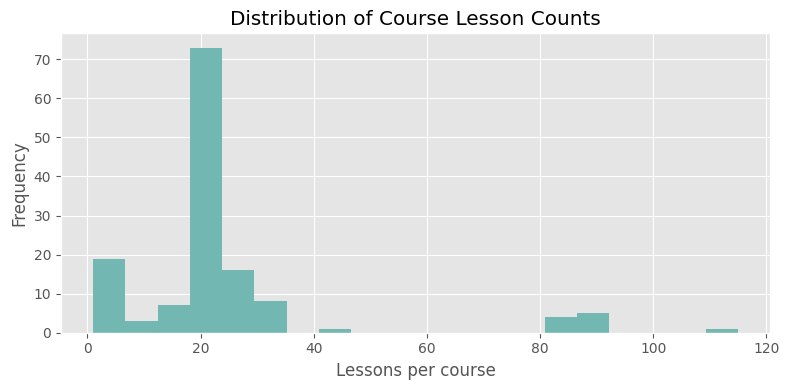

(   base_course_count  lessons_course_count  base_courses_missing_in_lessons  lessons_only_courses
 0                 82                   137                                0                    55,
                   block_name                                                          source_tables target_level  rows  cols     key_cols  is_key_unique  feature_count  new_feature_count                                                                                                            coverage_notes                                                                      important_warnings
 0  course_structure_features  [lessons, lesson_tasks, trainings, groups, homeworks, homework_items]    course_id   137    33  [course_id]           True             32                 32  Course structure is aggregated before any merge to the user-course base. Lessons are used as the stable course skeleton.  Homework-derived structure only covers homework rows that resolve to lesson resources.)

In [7]:
base_course_ids = set(users_courses_base_AGENT['course_id'].dropna().unique().tolist())
lesson_course_ids = set(dfs['lessons']['course_id'].dropna().unique().tolist())
course_hypothesis_table = pd.DataFrame([
    {
        'base_course_count': len(base_course_ids),
        'lessons_course_count': len(lesson_course_ids),
        'base_courses_missing_in_lessons': len(base_course_ids - lesson_course_ids),
        'lessons_only_courses': len(lesson_course_ids - base_course_ids),
    }
])

course_features_AGENT, course_feature_list, course_summary = build_course_structure_features(
    dfs['lessons'],
    dfs['lesson_tasks'],
    dfs['trainings'],
    dfs['groups'],
    dfs['homeworks'],
    dfs['homework_items'],
)
block_summaries.append(course_summary)

fig, ax = plt.subplots(figsize=(8, 4))
course_features_AGENT['course_lessons_count'].dropna().plot.hist(bins=20, ax=ax, color='#72B7B2')
ax.set_title('Distribution of Course Lesson Counts')
ax.set_xlabel('Lessons per course')
savefig('course_lessons_count_distribution_AGENT.png')
plt.show()

course_hypothesis_table, summary_frame(course_summary)

# 9. User-level aggregation and feature engineering

Why this step is needed:
The notebook needs user-level context, but it must be aggregated before any merge to the base.

What problem it solves:
It transforms raw user metadata and badge history into one row per `user_id`.

Input data:
`users`, `user_award_badges`, and `award_badges`.

Expected output:
`user_features_AGENT` keyed by `user_id`.

How it helps the final master table:
It contributes stable profile and platform-level enrichment without changing the user-course grain.

In [8]:
user_features_AGENT, user_feature_list, user_summary = build_users_base_features(
    dfs['users'],
    dfs['user_award_badges'],
    dfs['award_badges'],
    reference_timestamp,
)
block_summaries.append(user_summary)

summary_frame(user_summary), build_key_diagnostics(user_features_AGENT, [['user_id']])

(            block_name                             source_tables target_level   rows  cols   key_cols  is_key_unique  feature_count  new_feature_count                                                                                           coverage_notes                                                                                                   important_warnings
 0  users_base_features  [users, user_award_badges, award_badges]      user_id  90647    24  [user_id]           True             21                 21  User-level features are aggregated to one row per user_id before joining to the user-course base table.  Badge-based signals are platform-wide and should be interpreted as enrichment rather than course-specific behavior.,
     key_cols   rows  non_null_rows  unique_key_rows  duplicate_rows  is_unique
 0  [user_id]  90647          90647            90647               0       True)

# 10. User-lesson block

Why this step is needed:
Lesson progress is one of the clearest behavioral sources at user-course level.

What problem it solves:
It aggregates lesson-touch, lesson-progress, and solved-task signals while keeping the direct `users_course_id` grain.

Input data:
`user_lessons`, `lessons`, and the course structure block for ratio features.

Expected output:
`user_lessons_agg_AGENT` with one row per `users_course_id`.

How it helps the final master table:
It adds interpretable progression features such as touched lessons, solved lessons, furthest lesson reached, and progress ratios versus course structure.

In [9]:
user_lessons_agg_AGENT, user_lessons_feature_list, user_lessons_summary = build_user_lesson_features(
    dfs['user_lessons'],
    dfs['lessons'],
    course_features_AGENT,
)
block_summaries.append(user_lessons_summary)

summary_frame(user_lessons_summary)

del dfs['user_lessons']
gc.collect()

0

# 11. User-training block

Why this step is needed:
Training activity is a required part of the case framing, but it does not store `users_course_id` directly.

What problem it solves:
It validates the bridge from training attempts to the core user-course entity before aggregation.

Input data:
`user_trainings`, `trainings`, `lessons`, and the user-course base table.

Expected output:
A route-diagnostic table plus `user_trainings_agg_AGENT` at `users_course_id` grain.

How it helps the final master table:
It adds interpretable signals about training engagement, attempts, marks, and training progression depth.

In [10]:
training_route_check = (
    dfs['user_trainings'][['user_id', 'training_id']]
    .merge(
        dfs['trainings'][['id', 'lesson_id']].rename(columns={'id': 'training_id'}),
        on='training_id',
        how='left',
        validate='m:1',
    )
    .merge(
        dfs['lessons'][['id', 'course_id']].rename(columns={'id': 'lesson_id'}),
        on='lesson_id',
        how='left',
        validate='m:1',
    )
    .merge(
        users_courses_base_AGENT[[CORE_ENTITY_KEY, 'user_id', 'course_id']],
        on=['user_id', 'course_id'],
        how='left',
        validate='m:1',
    )
)
training_route_diagnostic = pd.DataFrame([
    {
        'rows_total': len(training_route_check),
        'missing_lesson_after_training_join': int(training_route_check['lesson_id'].isna().sum()),
        'missing_course_after_lesson_join': int(training_route_check['course_id'].isna().sum()),
        'matched_users_course_id_rows': int(training_route_check[CORE_ENTITY_KEY].notna().sum()),
        'matched_share': round(training_route_check[CORE_ENTITY_KEY].notna().mean(), 6),
    }
])

user_trainings_agg_AGENT, user_trainings_feature_list, user_trainings_summary = build_user_training_features(
    dfs['user_trainings'],
    dfs['trainings'],
    dfs['lessons'],
    users_courses_base_AGENT,
)
block_summaries.append(user_trainings_summary)

training_route_diagnostic, summary_frame(user_trainings_summary)

del dfs['user_trainings']
gc.collect()

17

# 12. User-answer block

Why this step is needed:
Answers are one of the richest engagement sources, but answer rows do not store `users_course_id` directly.

What problem it solves:
It first rejects the unsafe `task_id`-only bridge, then validates a resource-specific linkage design before aggregation.

Input data:
`user_answers`, `lessons`, `trainings`, `homeworks`, and the user-course base table.

Expected output:
Bridge diagnostics and `user_answers_agg_AGENT` at `users_course_id` grain.

How it helps the final master table:
It adds answer volume, answer timing, points, attempts, solved and skipped counts, and modality splits across lesson, training, and homework answers.

In [11]:
task_course_counts = (
    dfs['lesson_tasks']
    .merge(
        dfs['lessons'][['id', 'course_id']].rename(columns={'id': 'lesson_id'}),
        on='lesson_id',
        how='left',
        validate='m:1',
    )
    .groupby('task_id')['course_id']
    .nunique()
    .rename('task_course_nunique')
)
lesson_answer_task_check = dfs['user_answers'].loc[
    dfs['user_answers']['resource_type'] == 'Lesson',
    ['task_id']
].merge(task_course_counts, on='task_id', how='left', validate='m:1')
answer_task_hypothesis = pd.DataFrame([
    {
        'lesson_answer_rows': len(lesson_answer_task_check),
        'task_ids_with_single_course_share': round(lesson_answer_task_check['task_course_nunique'].eq(1).mean(), 6),
        'task_ids_with_multiple_courses_share': round(lesson_answer_task_check['task_course_nunique'].gt(1).mean(), 6),
        'max_courses_per_task_id': int(task_course_counts.max()),
    }
])

lesson_answer_bridge = dfs['user_answers'].loc[dfs['user_answers']['resource_type'] == 'Lesson', ['user_id', 'resource_id']].merge(
    dfs['lessons'][['id', 'course_id']].rename(columns={'id': 'resource_id'}),
    on='resource_id',
    how='left',
    validate='m:1',
)
training_answer_bridge = dfs['user_answers'].loc[dfs['user_answers']['resource_type'] == 'Training', ['user_id', 'resource_id']].merge(
    dfs['trainings'][['id', 'lesson_id']].rename(columns={'id': 'resource_id'}),
    on='resource_id',
    how='left',
    validate='m:1',
).merge(
    dfs['lessons'][['id', 'course_id']].rename(columns={'id': 'lesson_id'}),
    on='lesson_id',
    how='left',
    validate='m:1',
)
homework_bridge_map = (
    dfs['homeworks'].loc[dfs['homeworks']['resource_type'] == 'Lesson', ['id', 'resource_id']]
    .rename(columns={'id': 'resource_id', 'resource_id': 'lesson_id'})
    .merge(
        dfs['lessons'][['id', 'course_id']].rename(columns={'id': 'lesson_id'}),
        on='lesson_id',
        how='left',
        validate='m:1',
    )
)
homework_answer_bridge = dfs['user_answers'].loc[dfs['user_answers']['resource_type'] == 'Homework', ['user_id', 'resource_id']].merge(
    homework_bridge_map[['resource_id', 'course_id']],
    on='resource_id',
    how='left',
    validate='m:1',
)
answer_resource_diagnostic = pd.DataFrame([
    {
        'resource_type': 'Lesson',
        'rows_total': len(lesson_answer_bridge),
        'course_resolved_share': round(lesson_answer_bridge['course_id'].notna().mean(), 6),
    },
    {
        'resource_type': 'Training',
        'rows_total': len(training_answer_bridge),
        'course_resolved_share': round(training_answer_bridge['course_id'].notna().mean(), 6),
    },
    {
        'resource_type': 'Homework',
        'rows_total': len(homework_answer_bridge),
        'course_resolved_share': round(homework_answer_bridge['course_id'].notna().mean(), 6),
    },
])

user_answers_agg_AGENT, user_answers_feature_list, user_answers_summary = build_user_answer_features(
    dfs['user_answers'],
    dfs['lessons'],
    dfs['trainings'],
    dfs['homeworks'],
    users_courses_base_AGENT,
)
block_summaries.append(user_answers_summary)

answer_task_hypothesis, answer_resource_diagnostic, summary_frame(user_answers_summary)

del dfs['user_answers']
gc.collect()

40

# 13. Course-action block

Why this step is needed:
The case explicitly asks for interpretable course-activity patterns, and `wk_users_courses_actions` is the most direct source for that logic.

What problem it solves:
It aggregates direct course actions to the target grain and derives simple temporal windows that can later support decline-style features.

Input data:
`wk_users_courses_actions` and enrollment dates from the user-course base.

Expected output:
`course_actions_agg_AGENT` at `users_course_id` grain.

How it helps the final master table:
It adds volume, diversity, recency, active-day, and early-window action features without any ambiguous bridge logic.

In [12]:
course_actions_agg_AGENT, course_actions_feature_list, course_actions_summary = build_course_action_features(
    dfs['wk_users_courses_actions'],
    users_courses_base_AGENT,
)
block_summaries.append(course_actions_summary)

summary_frame(course_actions_summary)

del dfs['wk_users_courses_actions']
gc.collect()

41

# 14. Media block

Why this step is needed:
Media sessions capture viewing behavior that is relevant for both progress and risk interpretation.

What problem it solves:
It validates the resource bridge for lesson and group media sessions before aggregating them to the user-course grain.

Input data:
`wk_media_view_sessions`, `groups`, `lessons`, and the user-course base table.

Expected output:
Media-route diagnostics and `media_sessions_agg_AGENT` keyed by `users_course_id`.

How it helps the final master table:
It adds session counts, viewing completeness, modality splits, and media recency signals.

In [13]:
lesson_media_bridge = dfs['wk_media_view_sessions'].loc[
    dfs['wk_media_view_sessions']['resource_type'] == 'Lesson',
    ['viewer_id', 'resource_id']
].merge(
    dfs['lessons'][['id', 'course_id']].rename(columns={'id': 'resource_id'}),
    on='resource_id',
    how='left',
    validate='m:1',
)
group_media_bridge = dfs['wk_media_view_sessions'].loc[
    dfs['wk_media_view_sessions']['resource_type'] == 'Group',
    ['viewer_id', 'resource_id']
].merge(
    dfs['groups'][['id', 'lesson_id']].rename(columns={'id': 'resource_id'}),
    on='resource_id',
    how='left',
    validate='m:1',
).merge(
    dfs['lessons'][['id', 'course_id']].rename(columns={'id': 'lesson_id'}),
    on='lesson_id',
    how='left',
    validate='m:1',
)
media_route_diagnostic = pd.DataFrame([
    {
        'resource_type': 'Lesson',
        'rows_total': len(lesson_media_bridge),
        'course_resolved_share': round(lesson_media_bridge['course_id'].notna().mean(), 6),
    },
    {
        'resource_type': 'Group',
        'rows_total': len(group_media_bridge),
        'course_resolved_share': round(group_media_bridge['course_id'].notna().mean(), 6),
    },
])

media_sessions_agg_AGENT, media_feature_list, media_summary = build_media_features(
    dfs['wk_media_view_sessions'],
    dfs['groups'],
    dfs['lessons'],
    users_courses_base_AGENT,
)
block_summaries.append(media_summary)

media_route_diagnostic, summary_frame(media_summary)

del dfs['wk_media_view_sessions']
gc.collect()

40

# 15. Access-history block

Why this step is needed:
Access history provides the administrative time horizon within which behavioral events should be interpreted.

What problem it solves:
It converts raw access periods and activator classes into a compact user-course summary.

Input data:
`user_access_histories`.

Expected output:
`access_history_agg_AGENT` keyed by `users_course_id`.

How it helps the final master table:
It adds access duration, reopen or extension context, premium-access signals, and timeline anchors used later in time-aware feature engineering.

In [14]:
access_history_agg_AGENT, access_feature_list, access_summary = build_access_history_features(
    dfs['user_access_histories'],
)
block_summaries.append(access_summary)

summary_frame(access_summary)

del dfs['user_access_histories']
gc.collect()

88

# 16. Merge validation and assembly

Why this step is needed:
All prepared feature blocks must be merged only after they are already aggregated to their intended grain.

What problem it solves:
It validates each left join, checks coverage, confirms that `users_course_id` remains unique, and prevents silent row multiplication.

Input data:
The user-course base table together with the prepared user, course, lesson, training, answer, action, media, and access blocks.

Expected output:
`final_user_course_features_AGENT` before second-stage time features and a merge report.

How it helps the final master table:
It is the central integrity checkpoint for the entire feature dataset.

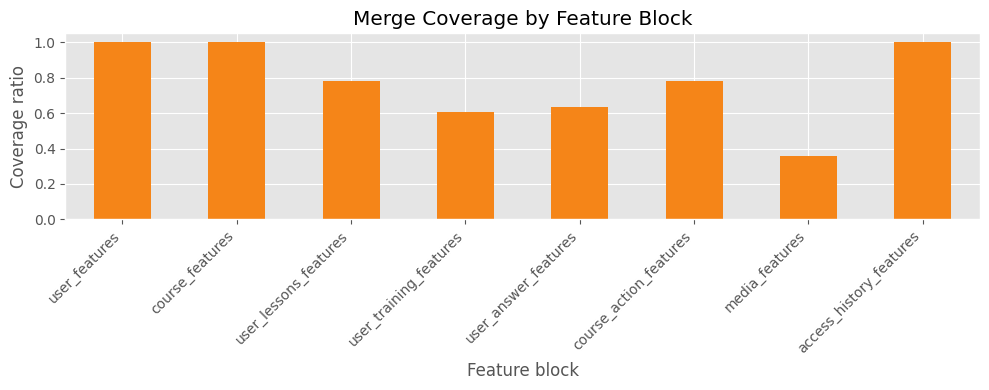

,right_name,join_key,left_rows_before,left_rows_after,right_rows,matched_rows,unmatched_rows,coverage_ratio,left_key_unique_before,left_key_unique_after,right_key_unique,row_multiplier_delta,added_columns,added_columns_mean_missing_share
0,user_features,user_id,267206,267206,90647,267206,0,1.000000,True,True,True,0,"sign_in_count, grade_id, timezone, wk_gender, d_wk_region_id, d_wk_municipal_id, d_wk_school_id, user_is_subscribed_flag, user_account_age_days, user_profile_age_days, user_grade_change_delay_days, user_has_grade_flag, user_has_timezone_flag, user_has_region_flag, user_has_municipal_flag, user_has_school_flag, user_has_gender_flag, user_badges_total_count, user_badges_unique_count, user_special_badges_count, user_badge_span_days, user_first_badge_at, user_last_badge_at",0.165536
1,course_features,course_id,267206,267206,137,267206,0,1.000000,True,True,True,0,"course_lessons_count, course_lessons_with_tasks_count, course_lessons_with_conspect_count, course_lessons_survival_count, course_lessons_scratch_count, course_lessons_attendance_count, course_lesson_number_max, course_lessons_max_points_sum, course_lessons_task_count_sum, course_video_duration_sum, course_video_duration_mean, course_lessons_with_tasks_share, course_lessons_with_conspect_share, course_lessons_survival_share, course_lessons_scratch_share, course_lessons_attendance_share, course_task_link_count, course_unique_task_count, course_required_task_count, course_required_task_share, course_trainings_count, course_training_task_templates_sum, course_training_difficulty_mean, course_groups_count, course_groups_with_video_count, course_groups_duration_sum, course_groups_actual_duration_sum, course_groups_with_video_share, course_homeworks_count, course_unique_homework_types, course_homework_item_count, course_homework_task_item_count",0.173388
2,user_lessons_features,users_course_id,267206,267206,216482,208629,58577,0.780780,True,True,True,0,"ul_lesson_rows, ul_lessons_touched_count, ul_lessons_solved_count, ul_video_visited_count, ul_video_viewed_count, ul_translation_visited_count, ul_points_sum, ul_points_mean, ul_solved_tasks_sum, ul_furthest_lesson_number, ul_task_count_gap_sum, ul_lessons_touched_ratio, ul_furthest_lesson_ratio, ul_points_ratio_vs_course, ul_solved_tasks_ratio_vs_course",0.311157
3,user_training_features,users_course_id,267206,267206,161517,161517,105689,0.604466,True,True,True,0,"training_records_count, training_unique_count, training_unique_lessons_count, training_started_count, training_checked_count, training_finished_count, training_attempts_sum, training_attempts_mean, training_attempts_max, training_submitted_answers_sum, training_solved_tasks_sum, training_earned_points_sum, training_mark_mean, training_mark_max, training_high_mark_count, training_first_activity_at, training_last_activity_at, training_max_lesson_number, training_activity_span_days",0.427562
4,user_answer_features,users_course_id,267206,267206,170022,170022,97184,0.636296,True,True,True,0,"answer_total_count, answer_task_unique_count, answer_resource_unique_count, answer_solved_count, answer_unsolved_count, answer_skipped_count, answer_partial_count, answer_attempts_sum, answer_attempts_mean, answer_attempts_max, answer_points_sum, answer_points_mean, answer_points_max, answer_first_at, answer_last_at, answer_active_days, answer_async_pending_count, answer_async_failed_count, answer_homework_count, answer_lesson_count, answer_training_count, answer_activity_span_days",0.364576
5,course_action_features,users_course_id,267206,267206,216342,208519,58687,0.780368,True,True,True,0,"action_total_count, action_unique_types_count, action_unique_lessons_count, action_active_days, action_first_at, action_last_at, action_first_14d_count, action_first_30d_count, action_last_14d_count, action_type_count_scratch_playground_visited, action_type_count_start_training, action_type_count_user_answer, action_type_count_visit_preparation_material, action_type_count_visit_translati

In [15]:
final_user_course_features_AGENT, merge_report_df = assemble_master_user_course_table(
    users_courses_base_AGENT,
    user_features_AGENT,
    course_features_AGENT,
    user_lessons_agg_AGENT,
    user_trainings_agg_AGENT,
    user_answers_agg_AGENT,
    course_actions_agg_AGENT,
    media_sessions_agg_AGENT,
    access_history_agg_AGENT,
)

fig, ax = plt.subplots(figsize=(10, 4))
merge_report_df.plot.bar(x='right_name', y='coverage_ratio', ax=ax, legend=False, color='#F58518')
ax.set_title('Merge Coverage by Feature Block')
ax.set_xlabel('Feature block')
ax.set_ylabel('Coverage ratio')
plt.xticks(rotation=45, ha='right')
savefig('merge_coverage_by_block_AGENT.png')
plt.show()

merge_report_df

# 17. Time-aware feature engineering

Why this step is needed:
Many business-relevant signals are not just about activity volume, but about delay, recency, inactivity, and early versus late engagement.

What problem it solves:
It turns timestamps already aligned at user-course grain into interpretable time-window features.

Input data:
The assembled master table and the notebook reference timestamp.

Expected output:
The final user-course master table with second-stage time-aware features.

How it helps the final master table:
It makes the dataset ready for later risk modeling and hypothesis testing about behavioral decline without building the target now.

In [16]:
final_user_course_features_AGENT, time_feature_list, time_feature_summary = build_time_window_features(
    final_user_course_features_AGENT,
    reference_timestamp,
)
block_summaries.append(time_feature_summary)

summary_frame(time_feature_summary)

,block_name,source_tables,target_level,rows,cols,key_cols,is_key_unique,feature_count,new_feature_count,coverage_notes,important_warnings
0,time_window_features,[final_master_user_course_features],users_course_id,267206,206,[users_course_id],True,23,23,Time-aware features are computed only after all blocks are aligned to the same user-course grain.,Observed-window features use access end as the default horizon and should be revisited if the modeling cutoff changes.


# 18. Final master-table review

Why this step is needed:
The final dataset must be audited before export.

What problem it solves:
It verifies the final grain, reviews missingness, checks feature-family balance, and visualizes several core numeric signals.

Input data:
The fully assembled user-course master table.

Expected output:
A final quality review with integrity checks, missingness review, and compact visual diagnostics.

How it helps the final master table:
It confirms that the dataset is ready for further EDA, later target attachment, and future model training.

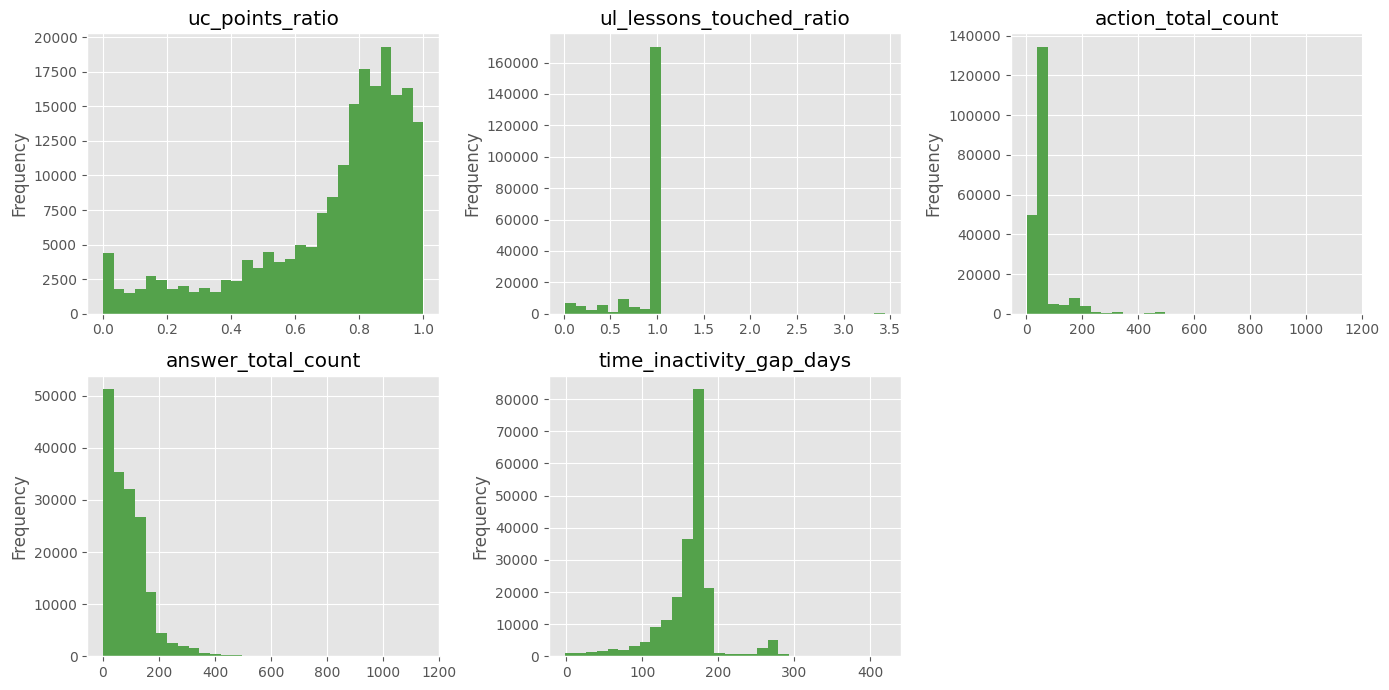

(            key_cols    rows  non_null_rows  unique_key_rows  duplicate_rows  is_unique
 0  [users_course_id]  267206         267206           267206               0       True,
    feature_family  columns_count  mean_missing_share
 3          course             37            0.190494
 10           time             23            0.306428
 2          answer             22            0.364575
 12       training             19            0.427562
 1          action             17            0.219632
 16           user             17            0.102478
 7           media             16            0.643537
 14             ul             15            0.311157
 13             uc             13            0.149937
 0          access             10            0.000344
 18             wk              7            0.404913
 5               d              3            0.373768
 8            sign              1            0.000000
 4         created              1            0.000000
 6         

In [17]:
final_key_check = build_key_diagnostics(final_user_course_features_AGENT, [[CORE_ENTITY_KEY]])
final_missingness = build_missingness_summary(final_user_course_features_AGENT)
feature_registry = pd.DataFrame({
    'column_name': final_user_course_features_AGENT.columns,
    'dtype': final_user_course_features_AGENT.dtypes.astype(str).values,
    'missing_share': final_user_course_features_AGENT.isna().mean().round(6).values,
})
feature_registry['feature_family'] = feature_registry['column_name'].str.split('_').str[0]
feature_family_summary = feature_registry.groupby('feature_family', as_index=False).agg(
    columns_count=('column_name', 'count'),
    mean_missing_share=('missing_share', 'mean'),
)

selected_numeric = [
    'uc_points_ratio',
    'ul_lessons_touched_ratio',
    'action_total_count',
    'answer_total_count',
    'time_inactivity_gap_days',
]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for axis, column in zip(axes, selected_numeric):
    final_user_course_features_AGENT[column].dropna().plot.hist(bins=30, ax=axis, color='#54A24B')
    axis.set_title(column)
for axis in axes[len(selected_numeric):]:
    axis.axis('off')
savefig('final_selected_feature_distributions_AGENT.png')
plt.show()

final_key_check, feature_family_summary.sort_values('columns_count', ascending=False), final_missingness.head(20)

# 19. Export of artifacts

Why this step is needed:
The notebook must leave behind reusable artifacts for later analysis and modeling.

What problem it solves:
It saves the final table, intermediate blocks, merge diagnostics, missingness review, and block summaries under `data/AGENT`.

Input data:
All prepared blocks, the final master table, and the notebook diagnostics.

Expected output:
CSV summaries, feature blocks, figures, and the final master table with `_AGENT` suffixes.

How it helps the final master table:
It makes the feature pipeline reproducible and ready for downstream work without touching raw files or the original `EDA.ipynb`.

In [18]:
block_summary_df = pd.DataFrame(block_summaries)

exports = {
    BLOCK_EXPORT_NAMES['users_courses_base']: users_courses_base_AGENT,
    BLOCK_EXPORT_NAMES['user_features']: user_features_AGENT,
    BLOCK_EXPORT_NAMES['course_features']: course_features_AGENT,
    BLOCK_EXPORT_NAMES['user_lessons']: user_lessons_agg_AGENT,
    BLOCK_EXPORT_NAMES['user_trainings']: user_trainings_agg_AGENT,
    BLOCK_EXPORT_NAMES['user_answers']: user_answers_agg_AGENT,
    BLOCK_EXPORT_NAMES['course_actions']: course_actions_agg_AGENT,
    BLOCK_EXPORT_NAMES['media']: media_sessions_agg_AGENT,
    BLOCK_EXPORT_NAMES['access']: access_history_agg_AGENT,
    BLOCK_EXPORT_NAMES['final_master']: final_user_course_features_AGENT,
}

for export_name, export_df in exports.items():
    save_dataframe(export_df, export_name)

save_summary(tables_overview, 'tables_overview_AGENT')
save_summary(id_cleaning_summary, 'id_cleaning_summary_AGENT')
save_summary(drop_summary, 'drop_service_summary_AGENT')
save_summary(entity_key_diagnostics, 'entity_key_diagnostics_AGENT')
save_summary(direct_link_diagnostics, 'direct_link_diagnostics_AGENT')
save_summary(block_summary_df, 'block_summaries_AGENT')
save_summary(merge_report_df, 'merge_report_AGENT')
save_summary(final_missingness, 'final_missingness_AGENT')
save_summary(feature_registry, 'feature_registry_AGENT')
save_summary(feature_family_summary, 'feature_family_summary_AGENT')

summary_frame({
    'final_rows': len(final_user_course_features_AGENT),
    'final_columns': final_user_course_features_AGENT.shape[1],
    'final_key_is_unique': final_user_course_features_AGENT[CORE_ENTITY_KEY].is_unique,
    'exports_saved_to': str(TABLES_DIR),
})

,final_rows,final_columns,final_key_is_unique,exports_saved_to
0,267206,206,True,C:\Repos\Xakaton\data\AGENT\tables
